In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train_data=pd.read_excel(r"C:\Users\shubh\Downloads\Data_Train.xlsx")

In [3]:
train_data.head(4)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218


In [4]:
train_data.tail(4)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [6]:
train_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
train_data['Total_Stops'].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
10678    False
10679    False
10680    False
10681    False
10682    False
Name: Total_Stops, Length: 10683, dtype: bool

In [8]:
train_data[train_data['Total_Stops'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [9]:
train_data.dropna(inplace=True)

In [10]:
train_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [11]:
train_data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [12]:
data=train_data.copy()

In [13]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [14]:
def change_into_DataTime(col):
    data[col]=pd.to_datetime(data[col])

In [15]:
for feature in ['Date_of_Journey','Dep_Time','Arrival_Time']:
    change_into_DataTime(feature)

C:\Users\shubh\AppData\Local\Temp\ipykernel_12712\729857193.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data[col]=pd.to_datetime(data[col])
C:\Users\shubh\AppData\Local\Temp\ipykernel_12712\729857193.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col]=pd.to_datetime(data[col])
C:\Users\shubh\AppData\Local\Temp\ipykernel_12712\729857193.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[col]=pd.to_datetime(data[col])


In [16]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [17]:
data.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time           datetime64[ns]
Arrival_Time       datetime64[ns]
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

In [18]:
data['Journey_Month']=data['Date_of_Journey'].dt.month

In [19]:
data['Journey_Year']=data['Date_of_Journey'].dt.year

In [20]:
data['Journey_Date']=data['Date_of_Journey'].dt.day

In [21]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Month,Journey_Year,Journey_Date
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-02-11 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,2019,24
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-02-11 05:50:00,2026-02-11 13:15:00,7h 25m,2 stops,No info,7662,5,2019,1


In [22]:
def extract_hour_min(df,col):
    df[col+"_hour"]=df[col].dt.hour
    df[col+"_minute"]=df[col].dt.minute
    return df.head(3)

In [23]:
extract_hour_min(data,"Arrival_Time")

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Month,Journey_Year,Journey_Date,Arrival_Time_hour,Arrival_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-02-11 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,2019,24,1,10
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-02-11 05:50:00,2026-02-11 13:15:00,7h 25m,2 stops,No info,7662,5,2019,1,13,15
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-02-11 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,6,2019,9,4,25


In [24]:
extract_hour_min(data,"Dep_Time")

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Month,Journey_Year,Journey_Date,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-02-11 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,3,2019,24,1,10,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-02-11 05:50:00,2026-02-11 13:15:00,7h 25m,2 stops,No info,7662,5,2019,1,13,15,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-02-11 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,6,2019,9,4,25,9,25


In [25]:
cols_to_drop=['Arrival_Time','Dep_Time']
data.drop(cols_to_drop,axis=1,inplace=True)

In [26]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Month,Journey_Year,Journey_Date,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,2019,24,1,10,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,2019,1,13,15,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,6,2019,9,4,25,9,25


In [27]:
data.shape

(10682, 16)

#problem: analyze when will most of the flight take off

In [28]:
def flight_dep_time(x):
    if(x>4) and (x<=8):
       return "Early Morning"
    elif (x>8) and (x<=12):
       return "Morning"
    elif (x>12) and (x<=16):
       return "Afternoon"
    elif  (x>16) and (x<=20):
       return "Evening"
    elif (x>20) and (x<=24):
       return "Night"
    else:
       return "Late night"

       

In [29]:
!pip install plotly
!pip install chart_studio
!pip install cufflinks

In [30]:
import plotly
import plotly.express
import cufflinks as cf
import plotly.express as px
from cufflinks.offline import go_offline
from plotly.offline import plot,iplot,init_notebook_mode,download_plotlyjs

init_notebook_mode(connected=True)
cf.go_offline()
cf.set_config_file(theme=None)


In [31]:
import plotly.express as px

vc = (
    data['Dep_Time_hour']
    .apply(flight_dep_time)
    .value_counts()
    .reset_index()
)

vc.columns = ['Departure_Time', 'Count']

fig = px.bar(
    vc,
    x='Departure_Time',
    y='Count',
    title='Flight Departure Time Distribution'
)

fig.show()


In [32]:
data['Duration']

0        2h 50m
1        7h 25m
2           19h
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680        3h
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: object

In [33]:
def preprocess_duration(x):
    if 'h' not in x:
        x='0h'+' '+x
    if 'm' not in x:
        x=x+' '+'0m'
    return x

In [34]:
data['Duration']=data['Duration'].apply(preprocess_duration)

In [35]:
data['Duration'][1]

'7h 25m'

In [36]:
int(data['Duration'][0].split(' ')[0][0:-1])

2

In [37]:
data['Duration'][0].split(' ')[1][0:-1]

'50'

In [38]:
data['Duration_hours']=data['Duration'].apply(lambda x:int(x.split(' ')[0][0:-1]))
data['Duration_minutes']=data['Duration'].apply(lambda x:int(x.split(' ')[1][0:-1]))


In [39]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Month,Journey_Year,Journey_Date,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute,Duration_hours,Duration_minutes
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,2019,24,1,10,22,20,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,2019,1,13,15,5,50,7,25


## whether duration impacts price or not?

In [40]:
data['Duration_total_mins']=data['Duration'].str.replace('h','*60').str.replace(' ','+').str.replace('m','*1').apply(eval)

In [41]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_Month',
       'Journey_Year', 'Journey_Date', 'Arrival_Time_hour',
       'Arrival_Time_minute', 'Dep_Time_hour', 'Dep_Time_minute',
       'Duration_hours', 'Duration_minutes', 'Duration_total_mins'],
      dtype='object')

<Axes: xlabel='Duration_total_mins', ylabel='Price'>

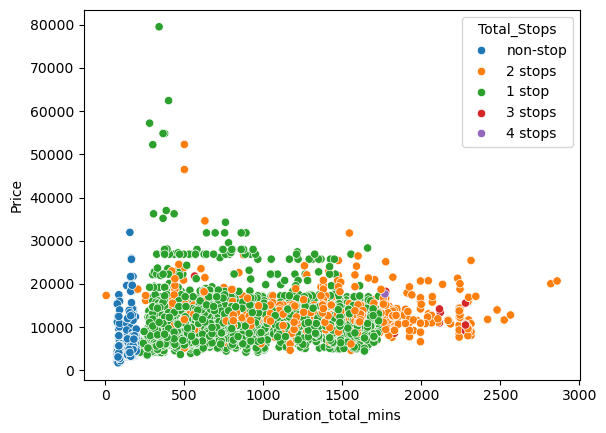

In [42]:
sns.scatterplot(x='Duration_total_mins',y='Price',hue='Total_Stops',data=data)

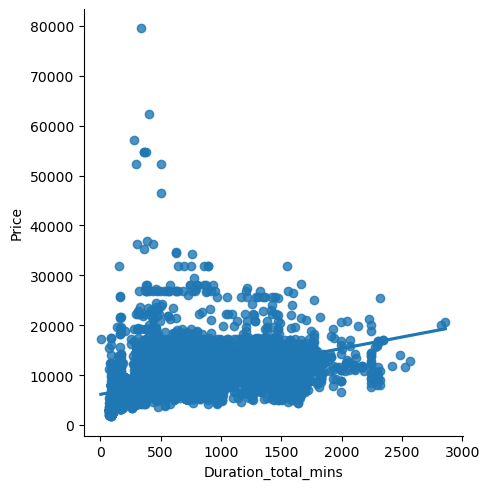

In [43]:
sns.lmplot(x='Duration_total_mins',y='Price',data=data)

## Problem:on which route jet airways extremely used?

In [44]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_Month',
       'Journey_Year', 'Journey_Date', 'Arrival_Time_hour',
       'Arrival_Time_minute', 'Dep_Time_hour', 'Dep_Time_minute',
       'Duration_hours', 'Duration_minutes', 'Duration_total_mins'],
      dtype='object')

In [45]:
data[data['Airline']=='Jet Airways'].groupby('Route').size().sort_values(ascending=False)

Route
CCU → BOM → BLR          930
DEL → BOM → COK          875
BLR → BOM → DEL          385
BLR → DEL                382
CCU → DEL → BLR          300
DEL → JAI → BOM → COK    207
BOM → HYD                207
DEL → AMD → BOM → COK    141
DEL → IDR → BOM → COK     86
DEL → NAG → BOM → COK     61
DEL → ATQ → BOM → COK     38
DEL → COK                 34
DEL → BHO → BOM → COK     29
DEL → BDQ → BOM → COK     28
DEL → LKO → BOM → COK     25
DEL → JDH → BOM → COK     23
CCU → GAU → BLR           22
DEL → MAA → BOM → COK     16
DEL → IXC → BOM → COK     13
BLR → MAA → DEL           10
BLR → BDQ → DEL            8
DEL → UDR → BOM → COK      7
BOM → DEL → HYD            5
CCU → BOM → PNQ → BLR      4
BLR → BOM → JDH → DEL      3
DEL → DED → BOM → COK      2
BOM → BDQ → DEL → HYD      2
BOM → IDR → DEL → HYD      1
BOM → VNS → DEL → HYD      1
BOM → DED → DEL → HYD      1
BOM → JDH → DEL → HYD      1
BOM → UDR → DEL → HYD      1
DEL → CCU → BOM → COK      1
dtype: int64

## Problem:Airlines vs Price Prediction

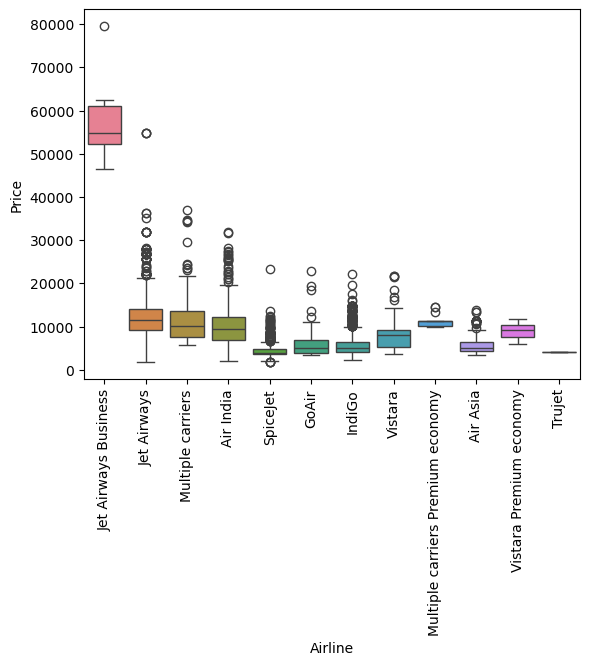

In [46]:
sns.boxplot(x='Airline',y='Price',hue='Airline',data=data.sort_values('Price',ascending=False))
plt.xticks(rotation='vertical')
plt.show()

## Feature Encoding

In [47]:
#select all categorical columns
cat_col=[col for col in data.columns if data[col].dtypes=='object']

In [48]:
#select all numerical column

num_col=[col for col in data.columns if data[col].dtypes!='object']


In [49]:
data['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [50]:
# one hot encoding
for sub_categories in data['Source'].unique():
        data['Source_'+sub_categories]=data['Source'].apply(lambda x:1 if x==sub_categories else 0)

In [51]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Month,...,Dep_Time_hour,Dep_Time_minute,Duration_hours,Duration_minutes,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,...,22,20,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,...,5,50,7,25,445,0,1,0,0,0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,6,...,9,25,19,0,1140,0,0,1,0,0


## Perform Target guided encoding on data

In [52]:
#feature target encoding of Airlines 

Airlines=data.groupby(['Airline'])['Price'].mean().sort_values().index


In [53]:
Airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='object', name='Airline')

In [54]:
dict_airlines={key:index for index,key in enumerate(Airlines,start=0)}

In [55]:
dict_airlines

{'Trujet': 0,
 'SpiceJet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara': 5,
 'Vistara Premium economy': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Multiple carriers Premium economy': 9,
 'Jet Airways': 10,
 'Jet Airways Business': 11}

In [56]:
data['Airline']=data['Airline'].map(dict_airlines)

In [57]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Month,...,Dep_Time_hour,Dep_Time_minute,Duration_hours,Duration_minutes,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,3,...,22,20,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,...,5,50,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,6,...,9,25,19,0,1140,0,0,1,0,0


In [58]:
data['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [59]:
data['Destination'].replace('New Delhi','Delhi',inplace=True)

In [60]:
data['Destination'].unique()

array(['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad'],
      dtype=object)

In [61]:
destination=data.groupby(['Destination'])['Price'].mean().sort_values().index

In [62]:
destination

Index(['Kolkata', 'Hyderabad', 'Delhi', 'Banglore', 'Cochin'], dtype='object', name='Destination')

In [63]:
dict_destination={key:index for index,key in enumerate(destination,start=0)}

In [64]:
dict_destination

{'Kolkata': 0, 'Hyderabad': 1, 'Delhi': 2, 'Banglore': 3, 'Cochin': 4}

In [65]:
data['Destination']=data['Destination'].map(dict_destination)

In [66]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Month,...,Dep_Time_hour,Dep_Time_minute,Duration_hours,Duration_minutes,Duration_total_mins,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2019-03-24,Banglore,2,BLR → DEL,2h 50m,non-stop,No info,3897,3,...,22,20,2,50,170,1,0,0,0,0
1,7,2019-05-01,Kolkata,3,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,5,...,5,50,7,25,445,0,1,0,0,0
2,10,2019-06-09,Delhi,4,DEL → LKO → BOM → COK,19h 0m,2 stops,No info,13882,6,...,9,25,19,0,1140,0,0,1,0,0


In [67]:
##manual label encoding

data['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [68]:
stop={'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}

In [69]:
data['Total_Stops']=data['Total_Stops'].map(stop)

In [70]:
data['Total_Stops']

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10682, dtype: int64

In [71]:
#Remove unnecessary features

data['Additional_Info'].value_counts()/len(data)*100


Additional_Info
No info                         78.112713
In-flight meal not included     18.554578
No check-in baggage included     2.995694
1 Long layover                   0.177869
Change airports                  0.065531
Business class                   0.037446
No Info                          0.028085
1 Short layover                  0.009362
Red-eye flight                   0.009362
2 Long layover                   0.009362
Name: count, dtype: float64

In [72]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_Month',
       'Journey_Year', 'Journey_Date', 'Arrival_Time_hour',
       'Arrival_Time_minute', 'Dep_Time_hour', 'Dep_Time_minute',
       'Duration_hours', 'Duration_minutes', 'Duration_total_mins',
       'Source_Banglore', 'Source_Kolkata', 'Source_Delhi', 'Source_Chennai',
       'Source_Mumbai'],
      dtype='object')

In [73]:
data.drop(columns=['Additional_Info','Source','Date_of_Journey','Duration_total_mins','Journey_Year','Route','Duration'],axis=1,inplace=True)

In [74]:
data.head(4)

,Airline,Destination,Total_Stops,Price,Journey_Month,Journey_Date,Arrival_Time_hour,Arrival_Time_minute,Dep_Time_hour,Dep_Time_minute,Duration_hours,Duration_minutes,Source_Banglore,Source_Kolkata,Source_Delhi,Source_Chennai,Source_Mumbai
0,3,2,0,3897,3,24,1,10,22,20,2,50,1,0,0,0,0
1,7,3,2,7662,5,1,13,15,5,50,7,25,0,1,0,0,0
2,10,4,2,13882,6,9,4,25,9,25,19,0,0,0,1,0,0
3,3,3,1,6218,5,12,23,30,18,5,5,25,0,1,0,0,0


## Detect Outliers

In [75]:
def plot(df,col):
    fig,(ax1,ax2,ax3)=plt.subplots(3,1)
    sns.distplot(df[col],ax=ax1)
    sns.boxplot(x=df[col],ax=ax2)
    sns.distplot(df[col],ax=ax3,kde=False)


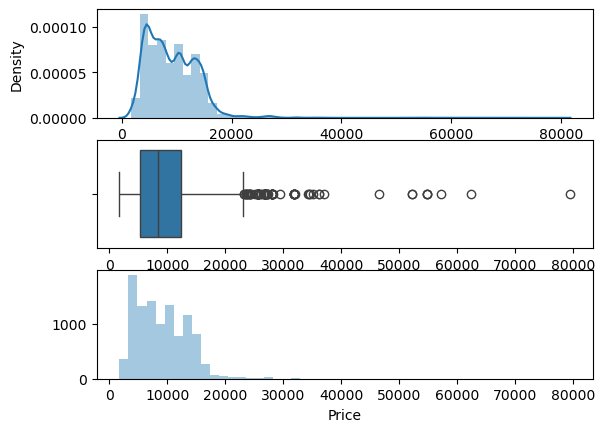

In [76]:
plot(data,'Price')

In [77]:
## find outliers

q1=data['Price'].quantile(0.25)
q3=data['Price'].quantile(0.75)

iqr=q3-q1;
maximum=q3+1.5*iqr
minimum=q1-1.5*iqr


outliers=[price for price in data['Price'] if price>maximum or price<minimum]

In [78]:
maximum

np.float64(23017.0)

In [79]:
minimum

np.float64(-5367.0)

In [80]:
#replace outliers with median

data['Price']=np.where(data['Price']>=35000 ,data['Price'].median(),data['Price'])

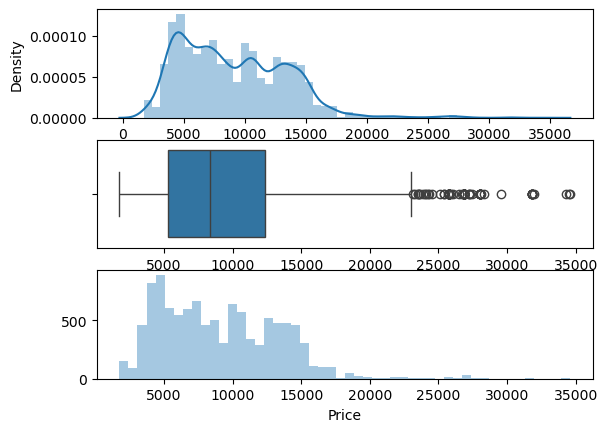

In [81]:
plot(data,'Price')

## Perform feature selection

In [82]:
X=data.drop(['Price'],axis=1)
y=data['Price']

In [83]:
from sklearn.feature_selection import mutual_info_regression

In [84]:
imp=mutual_info_regression(X,y)

In [85]:
imp

array([1.31049152, 1.0598415 , 0.79195873, 0.63307028, 0.37451608,
       1.13467561, 0.89665488, 0.91953691, 0.75427475, 1.11731712,
       0.67502605, 0.39634782, 0.45871664, 0.51887194, 0.12603297,
       0.19998819])

In [86]:
imp_features=pd.DataFrame(imp,index=X.columns)


In [87]:
imp_features.columns=['Importance']

In [88]:
imp_features.sort_values(by='Importance',ascending=False)

,Importance
Airline,1.310492
Arrival_Time_hour,1.134676
Duration_hours,1.117317
Destination,1.059841
Dep_Time_hour,0.919537
Arrival_Time_minute,0.896655
Total_Stops,0.791959
Dep_Time_minute,0.754275
Duration_minutes,0.675026
Journey_Month,0.633070


### Build ML model

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42
)

In [91]:
from sklearn.ensemble import RandomForestRegressor

In [92]:
ml_model=RandomForestRegressor()

In [93]:
ml_model.fit(X_train,y_train)

RandomForestRegressor()

In [94]:
y_pred=ml_model.predict(X_test)

In [95]:
y_pred

array([16808.36,  5311.3 ,  8806.47, ...,  3494.48,  6231.4 ,  6874.17])

In [96]:
from sklearn import metrics

In [97]:
metrics.r2_score(y_test,y_pred)

0.8130568106679688

## Lets save model

In [98]:
import pickle

In [99]:
file=open(r"C:\Users\shubh\OneDrive\Desktop\Flight_Prediction/rf_random.pkl","wb")

In [100]:
pickle.dump(ml_model,file)

In [101]:
model=open(r"C:\Users\shubh\OneDrive\Desktop\Flight_Prediction/rf_random.pkl","rb")

In [102]:
#checking model is saved correctly

In [103]:
forest=pickle.load(model)

In [104]:
y_pred=forest.predict(X_test)

In [105]:
metrics.r2_score(y_test,y_pred)

0.8130568106679688

In [106]:
def mape(y_true,y_pred):
    y_true,y_pred=np.array(y_true),np.array(y_pred)
    return np.mean(np.abs(y_true-y_pred)/y_true)*100

In [107]:
mape(y_test,y_pred)

np.float64(13.15651844648657)

In [108]:
def predict(ml_model):
    model=ml_model.fit(X_train,y_train)
    print("Training Score:{}".format(model.score(X_train,y_train)))
    y_prediction=model.predict(X_test)
    print("Prediction are:{}".format(y_prediction))
    print("\n")
    r2_score=metrics.r2_score(y_test,y_prediction)
    print("r2_score :{}".format(r2_score))
    print("MAE :{}".format(metrics.mean_absolute_error(y_test,y_prediction)))
    print("MSE :{}".format(metrics.mean_squared_error(y_test,y_prediction)))
    print("RMSE :{}".format(np.sqrt(metrics.mean_squared_error(y_test,y_prediction))))
    print("MSE :{}".format(mape(y_test,y_prediction)))
    sns.distplot(y_test-y_prediction)
    
        

Training Score:0.951174857094472
Prediction are:[16876.61  5214.5   8962.85 ...  3461.04  6501.34  6936.09]


r2_score :0.8102603259842149
MAE :1180.8268309056787
MSE :3693776.014388521
RMSE :1921.919877203137
MSE :13.234197240605216


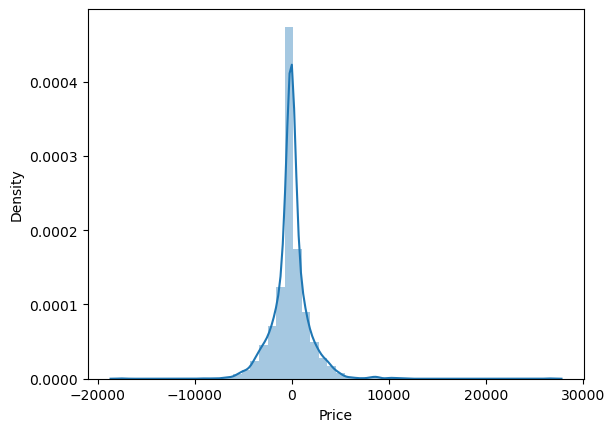

In [109]:
predict(RandomForestRegressor())

Training Score:0.966591628243878
Prediction are:[16840.  4959.  8085. ...  3419.  5797.  6442.]


r2_score :0.6768520654423591
MAE :1403.5629352302508
MSE :6290914.622678772
RMSE :2508.16957614089
MSE :15.46795624779573


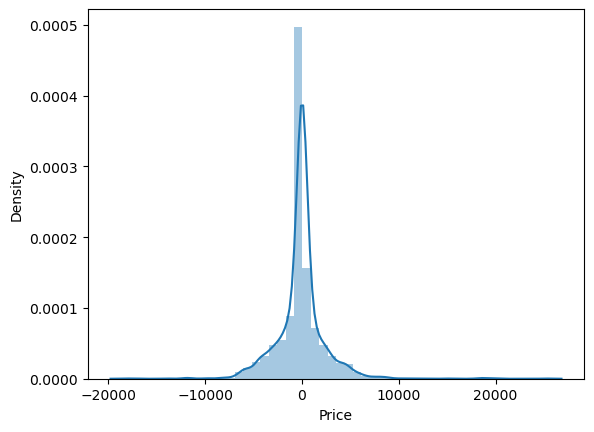

In [110]:
from sklearn.tree import DecisionTreeRegressor
predict(DecisionTreeRegressor())

## Hypertune Model

In [111]:
RandomForestRegressor()

RandomForestRegressor()

In [112]:
from sklearn.model_selection import RandomizedSearchCV

In [113]:
reg_rf=RandomForestRegressor()

In [116]:
n_estimators=[int(x) for x in np.linspace(start=100,stop=1200,num=6)]
max_features=["auto","sqrt"]
max_depth=[int(x) for x in np.linspace(start=5,stop=30,num=4)]
min_samples_split=[5,10,15,20]

In [117]:
random_grid={
    'n_estimators':n_estimators,
    'max_features':max_features,
    'max_depth':max_depth,
    'min_samples_split':min_samples_split
}

In [118]:
random_grid

{'n_estimators': [100, 320, 540, 760, 980, 1200],
 'max_features': ['auto', 'sqrt'],
 'max_depth': [5, 13, 21, 30],
 'min_samples_split': [5, 10, 15, 20]}

In [119]:
rf_random=RandomizedSearchCV(estimator=reg_rf,param_distributions=random_grid,cv=3,n_jobs=-1,verbose=2)

In [120]:
rf_random.fit(X_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 13, 21, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_split': [5, 10, 15, 20],
                                        'n_estimators': [100, 320, 540, 760,
                                                         980, 1200]},
                   verbose=2)

In [122]:
rf_random.best_params_

{'n_estimators': 320,
 'min_samples_split': 5,
 'max_features': 'sqrt',
 'max_depth': 30}

In [124]:
rf_random.best_estimator_

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_split=5,
                      n_estimators=320)

In [126]:
rf_random.best_score_

np.float64(0.8038981497827286)